In [69]:
import pandas as pd


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df=pd.read_csv("c:\\Users\\a\\Downloads\\india_housing_prices.csv")

In [72]:
df.head(2)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


In [73]:
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

***Data Acquisition, Cleaning, and Exploratory Analysis***

In [74]:
df.shape

(250000, 23)

In [75]:
(df.isnull().sum() / df.shape[0]) * 100

ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [78]:
df['Locality'] = df['Locality'].astype('category')


memory check

In [79]:
# Step 1: Memory usage before conversion
before_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage before conversion: {before_mem / 1024**2:.2f} MB")

# Step 2: Convert object columns to category
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].apply(lambda x: x.astype('category'))

# Step 3: Memory usage after conversion
after_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage after conversion: {after_mem / 1024**2:.2f} MB")



Memory usage before conversion: 194.04 MB
Memory usage after conversion: 24.41 MB


Numeric columns

In [80]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [81]:
# i check skew data for numeric columns
df.skew(numeric_only=True)

ID                  0.000000
BHK                 0.000543
Size_in_SqFt        0.000796
Price_in_Lakhs      0.008206
Price_per_SqFt      2.318668
Year_Built         -0.000167
Floor_No            0.005311
Total_Floors       -0.000666
Age_of_Property     0.000167
Nearby_Schools     -0.001258
Nearby_Hospitals    0.001099
dtype: float64

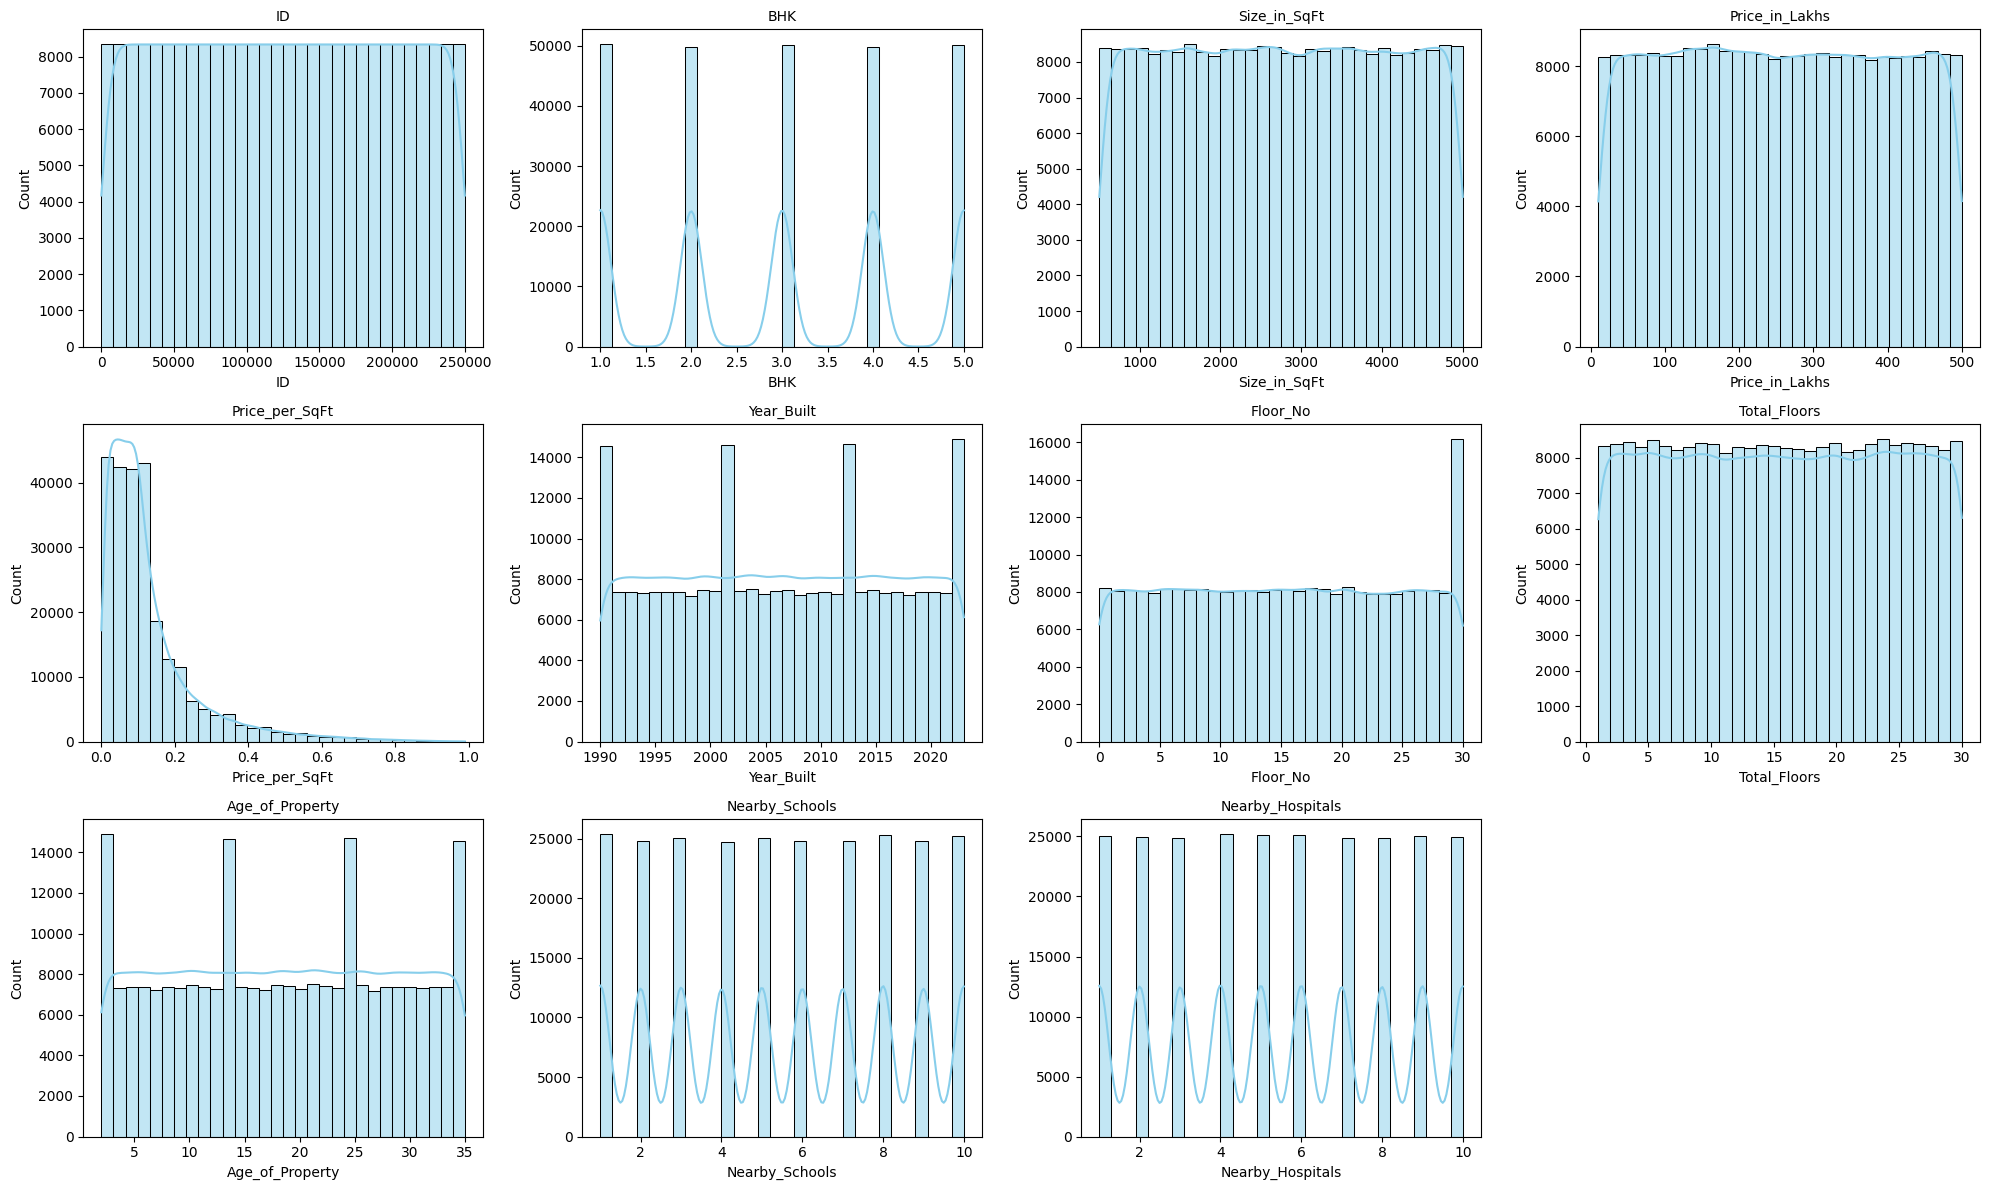

<Figure size 640x480 with 0 Axes>

In [82]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot each numeric column
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f'{col}', fontsize=10)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.savefig("numeric_columns_distribution.png",)  # saves as PNG
plt.show()

Most variables are approximately symmetric, except Price_per_SqFt, which is strongly right‑skewed. This insight guides preprocessing: apply transformations to skewed features while leaving symmetric ones unchanged.

Categorical colimns

In [83]:
df.describe(include=["object","category"])

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000,250000
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Odisha,Coimbatore,Locality_296,Villa,Unfurnished,High,No,Yes,Pool,West,Broker,Under_Construction
freq,12681,6461,567,83744,83408,83705,125456,125233,10218,62757,83479,125035


Outlier detection with IQR:

In [84]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    outlier_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    }

# Convert to DataFrame for readability
report_df = pd.DataFrame(outlier_report).T
print(report_df)


                        Q1         Q3        IQR  Lower Bound  Upper Bound  \
ID                62500.75  187500.25  124999.50  -124998.500   374999.500   
BHK                   2.00       4.00       2.00       -1.000        7.000   
Size_in_SqFt       1623.00    3874.00    2251.00    -1753.500     7250.500   
Price_in_Lakhs      132.55     376.88     244.33     -233.945      743.375   
Price_per_SqFt        0.05       0.16       0.11       -0.115        0.325   
Year_Built         1998.00    2015.00      17.00     1972.500     2040.500   
Floor_No              7.00      23.00      16.00      -17.000       47.000   
Total_Floors          8.00      23.00      15.00      -14.500       45.500   
Age_of_Property      10.00      27.00      17.00      -15.500       52.500   
Nearby_Schools        3.00       8.00       5.00       -4.500       15.500   
Nearby_Hospitals      3.00       8.00       5.00       -4.500       15.500   

                  Outlier Count  
ID                          0

Visualizations

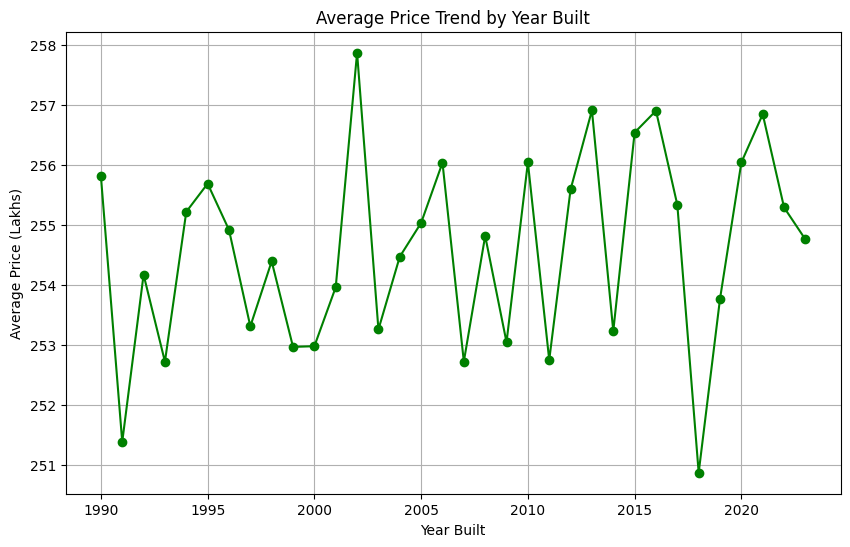

In [85]:
# Step 1: Group by year and compute average price
yearly_avg = df.groupby('Year_Built')['Price_in_Lakhs'].mean().sort_index()

# Step 2: Plot the average price trend
plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index, yearly_avg.values, color='green', marker='o')

# Step 3: Add labels and title
plt.title("Average Price Trend by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Price (Lakhs)")
plt.grid(True)
plt.show()


C:\Users\a\AppData\Local\Temp\ipykernel_17484\1639832871.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby('State')['Price_in_Lakhs'].mean()


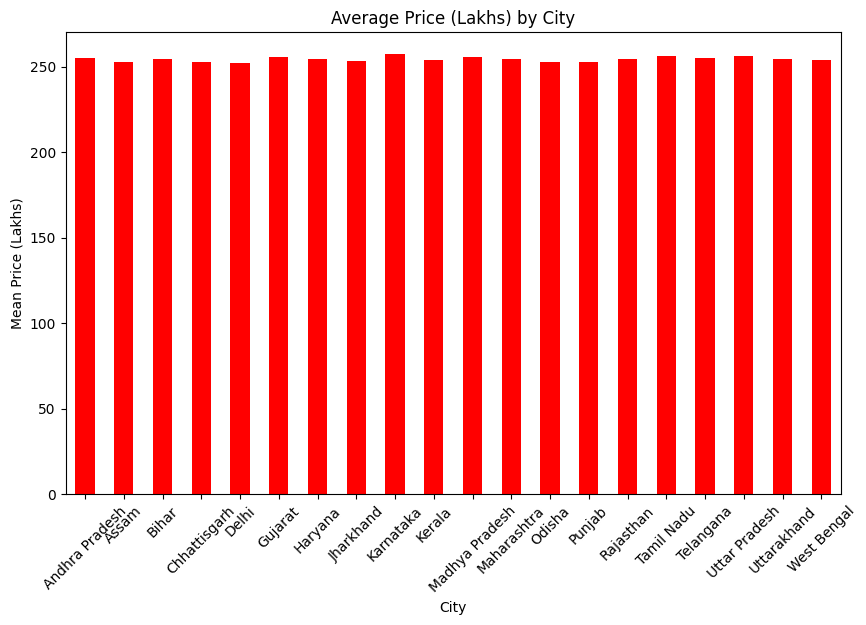

In [86]:
# Example: numeric column = 'Price_in_Lakhs', categorical column = 'City'
mean_values = df.groupby('State')['Price_in_Lakhs'].mean()

# Plot using df.plot.bar()
mean_values.plot.bar(color='red', figsize=(10,6))

# Add title and axis labels
plt.title("Average Price (Lakhs) by City")
plt.xlabel("City")
plt.ylabel("Mean Price (Lakhs)")
plt.xticks(rotation=45)  # rotate labels for readability
plt.show()

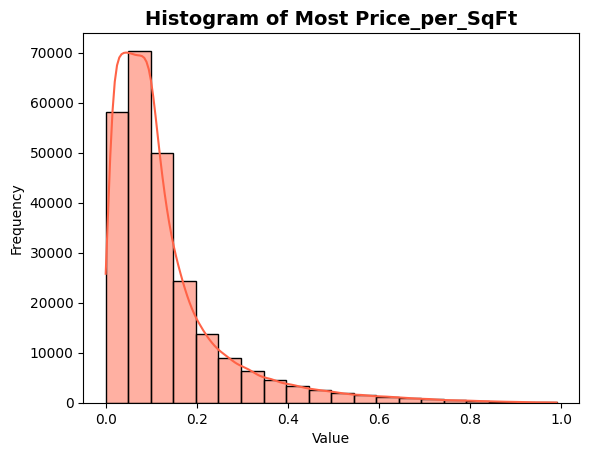

In [87]:
sns.histplot(df['Price_per_SqFt'], bins=20, kde=True, color="tomato")

plt.title("Histogram of Most Price_per_SqFt", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

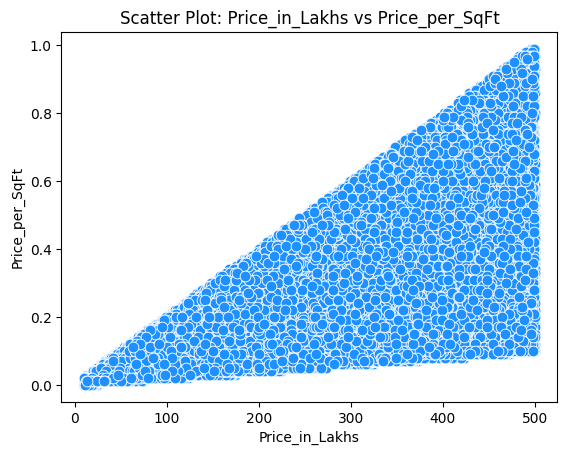

In [88]:
# Example: numeric columns = 'income' and 'spending'
sns.scatterplot(x=df['Price_in_Lakhs'], y=df['Price_per_SqFt'], color="dodgerblue", s=60)

plt.title("Scatter Plot: Price_in_Lakhs vs Price_per_SqFt")
plt.xlabel("Price_in_Lakhs")
plt.ylabel("Price_per_SqFt")
plt.show()

C:\Users\a\AppData\Local\Temp\ipykernel_17484\2057220585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)


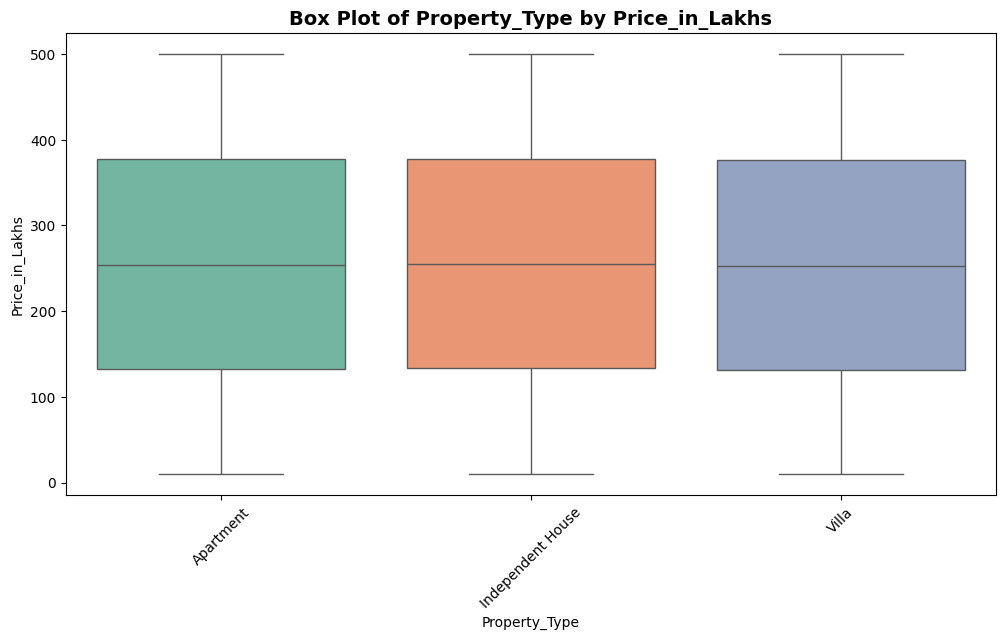

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Example: numeric column = 'sales', categorical column = 'region'
sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)

plt.title("Box Plot of Property_Type by Price_in_Lakhs", fontsize=14, fontweight='bold')
plt.xlabel("Property_Type")
plt.ylabel("Price_in_Lakhs")
plt.xticks(rotation=45)
plt.show()


Correlation heat map:

In [90]:
df.corr(numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,-0.001718,-0.002293,-0.001636,-0.001344,0.002734,-0.000214,0.003382,-0.002734,-0.001203,0.001429
BHK,-0.001718,1.000000,-0.001033,-0.000980,0.001174,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.002293,-0.001033,1.000000,-0.002529,-0.614533,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price_in_Lakhs,-0.001636,-0.000980,-0.002529,1.000000,0.555625,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,-0.001344,0.001174,-0.614533,0.555625,1.000000,-0.001212,-0.001906,0.004175,0.001212,-0.000094,-0.000145
Year_Built,0.002734,0.000917,0.004135,0.002714,-0.001212,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,-0.000214,0.001263,-0.002775,-0.001719,-0.001906,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,0.003382,-0.002862,-0.003451,0.001283,0.004175,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.002734,-0.000917,-0.004135,-0.002714,0.001212,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.001203,-0.000762,0.001966,0.000155,-0.000094,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246


<Axes: >

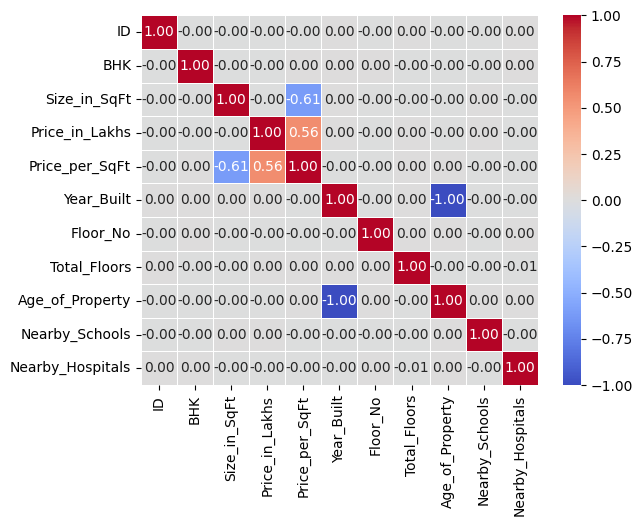

In [91]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

"""I used a correlation heatmap to identify relationship 
between numerical fetures.
I found that price_in_lakhs and Price_per_SqFT has a moderate positve
correlation(0.56),while Size_in_SqFt and Price_per_SqFt showed a moderate
negative correlation(-0.61). Year_built and Age_of_property had a perfect negative correlation (-1.0) which is expected because older ,properties have earlier contrucation years.
"""

Imputation strategy comparison.

In [92]:
# Step 1: Identify skewness for numeric columns
from scipy.stats import skew
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Step 2: Pick top 2 columns with highest absolute skewness
top2_cols = skew_values.abs().sort_values(ascending=False).head(2).index
print("Top 2 skewed columns:", top2_cols.tolist())

# Step 3: Compute mean and median for each column (before imputation)
for col in top2_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_values[col]:.2f}")

# Step 4: Choose imputation strategy based on skewness direction
# Positively skewed → median; Negatively skewed → median (since mean is pulled away)
for col in top2_cols:
    chosen_val = df[col].median()
    df[col] = df[col].fillna(chosen_val)

Top 2 skewed columns: ['Price_per_SqFt', 'Price_in_Lakhs']
Price_per_SqFt: mean=0.13, median=0.09, skew=2.32
Price_in_Lakhs: mean=254.59, median=253.87, skew=0.01


Spearman rank correlation

In [93]:
# Step 1: Pearson correlation (linear relationships)
pearson_corr = df.corr(method='pearson',	numeric_only=True)

# Step 2: Spearman correlation (rank-based monotonic relationships)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Step 3: Absolute difference matrix
diff_matrix = (spearman_corr - pearson_corr).abs()

# Step 4: Extract top 3 pairs with largest differences
pairs = []
cols = df.select_dtypes(include=['int64','float64']).columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], diff_matrix.loc[cols[i], cols[j]]))

top3 = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

# Step 5: Print results
print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

print("\nTop 3 pairs with largest |Spearman - Pearson| difference:")
for c1, c2, diff in top3:
    print(f"{c1} vs {c2}: |Spearman-Pearson|={diff:.3f}, "
          f"Pearson={pearson_corr.loc[c1,c2]:.3f}, Spearman={spearman_corr.loc[c1,c2]:.3f}")


Pearson Correlation Matrix:
                         ID       BHK  Size_in_SqFt  Price_in_Lakhs  \
ID                1.000000 -0.001718     -0.002293       -0.001636   
BHK              -0.001718  1.000000     -0.001033       -0.000980   
Size_in_SqFt     -0.002293 -0.001033      1.000000       -0.002529   
Price_in_Lakhs   -0.001636 -0.000980     -0.002529        1.000000   
Price_per_SqFt   -0.001344  0.001174     -0.614533        0.555625   
Year_Built        0.002734  0.000917      0.004135        0.002714   
Floor_No         -0.000214  0.001263     -0.002775       -0.001719   
Total_Floors      0.003382 -0.002862     -0.003451        0.001283   
Age_of_Property  -0.002734 -0.000917     -0.004135       -0.002714   
Nearby_Schools   -0.001203 -0.000762      0.001966        0.000155   
Nearby_Hospitals  0.001429  0.001162     -0.001695       -0.002769   

                  Price_per_SqFt  Year_Built  Floor_No  Total_Floors  \
ID                     -0.001344    0.002734 -0.000214    

In [94]:
df.head(2)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction


Grouped aggregation. 

In [95]:
result = df.groupby('Amenities')['Price_in_Lakhs'].agg(['mean', 'std', 'count'])

print(result)

                                                mean         std  count
Amenities                                                              
Clubhouse                                 253.987368  142.770568  10010
Clubhouse, Garden                         251.494313  142.693654   2497
Clubhouse, Garden, Gym                    260.157847  139.889419    864
Clubhouse, Garden, Gym, Playground        262.686259  141.104290    425
Clubhouse, Garden, Gym, Playground, Pool  253.110220  141.371533    410
...                                              ...         ...    ...
Pool, Playground, Gym                     252.854667  140.565174    872
Pool, Playground, Gym, Clubhouse          244.953142  145.816361    401
Pool, Playground, Gym, Clubhouse, Garden  257.064712  140.165338    416
Pool, Playground, Gym, Garden             244.016402  144.669252    428
Pool, Playground, Gym, Garden, Clubhouse  244.648828  141.896796    418

[325 rows x 3 columns]


C:\Users\a\AppData\Local\Temp\ipykernel_17484\562467395.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('Amenities')['Price_in_Lakhs'].agg(['mean', 'std', 'count'])


In [96]:
df.to_csv("cleaned_Housing_data.csv", index=False)